# 🚛 KNN K=5 — Predicción de Mantenimiento de Camiones Mineros

<div style="background: linear-gradient(135deg, #0F172A 0%, #1E293B 100%); border-left: 4px solid #38BDF8; border-radius: 8px; padding: 18px 24px; font-family: 'Segoe UI', sans-serif; color: #F1F5F9; margin: 12px 0;">
  <h3 style="margin:0 0 8px 0; color:#38BDF8; font-size:1.1em;">📋 Pipeline completo</h3>
  <ol style="margin:0; padding-left:18px; color:#94A3B8; line-height:1.9; font-size:0.9em;">
    <li><b style="color:#F1F5F9;">Sube tu dataset</b> (.xlsx con header en fila 3)</li>
    <li><b style="color:#F1F5F9;">Instala dependencias</b> y preprocesa los datos</li>
    <li><b style="color:#F1F5F9;">Entrena KNN K=5</b> con validación cruzada</li>
    <li><b style="color:#F1F5F9;">Visualiza métricas</b> e importancia de variables</li>
    <li><b style="color:#F1F5F9;">Descarga</b> el Excel con predicciones e insights</li>
  </ol>
</div>

> ⚙️ **Modelo:** K-Nearest Neighbors · K=5 · Distancia Euclidiana · Normalización StandardScaler


In [1]:
# ╔══════════════════════════════════════════╗
# ║  CELDA 1 · Instalar dependencias         ║
# ╚══════════════════════════════════════════╝
!pip install openpyxl scikit-learn pandas numpy matplotlib seaborn -q
print("✅ Dependencias listas")


✅ Dependencias listas


In [2]:
# ╔══════════════════════════════════════════╗
# ║  CELDA 2 · Subir el dataset              ║
# ╚══════════════════════════════════════════╝
from google.colab import files
import io, pandas as pd

print("📂 Selecciona tu archivo .xlsx (camiones_mineros_dataset.xlsx)")
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df_raw = pd.read_excel(io.BytesIO(uploaded[filename]), header=2)

print(f"\n✅ Dataset cargado: {df_raw.shape[0]} filas × {df_raw.shape[1]} columnas")
print(f"   Columnas: {df_raw.columns.tolist()}")
df_raw.head(3)


📂 Selecciona tu archivo .xlsx (camiones_mineros_dataset.xlsx)


Saving camiones_mineros_dataset.xlsx to camiones_mineros_dataset.xlsx

✅ Dataset cargado: 150 filas × 14 columnas
   Columnas: ['ID_Camion', 'Modelo', 'Año_Fabricacion', 'Horas_Operacion', 'Temperatura_Motor_C', 'Presion_Aceite_bar', 'Nivel_Combustible_L', 'Velocidad_Promedio_kmh', 'Carga_Toneladas', 'Vibracion_mm_s', 'Eficiencia_Combustible', 'Km_Recorridos', 'Dias_Ultimo_Mantenimiento', 'Estado_Mantenimiento']


,ID_Camion,Modelo,Año_Fabricacion,Horas_Operacion,Temperatura_Motor_C,Presion_Aceite_bar,Nivel_Combustible_L,Velocidad_Promedio_kmh,Carga_Toneladas,Vibracion_mm_s,Eficiencia_Combustible,Km_Recorridos,Dias_Ultimo_Mantenimiento,Estado_Mantenimiento
0,CAM-001,BelAZ 75710,2011,1319,119.5,3.48,571.2,14.6,322.2,6.77,1.36,11769,23,Mantenimiento Próximo
1,CAM-002,Komatsu 960E,2013,17059,111.1,4.74,2724.3,41.6,225.9,5.67,0.80,641709,40,Operativo Normal
2,CAM-003,BelAZ 75710,2016,11649,91.7,3.36,2901.7,14.6,214.0,4.63,0.92,117791,11,Operativo Normal


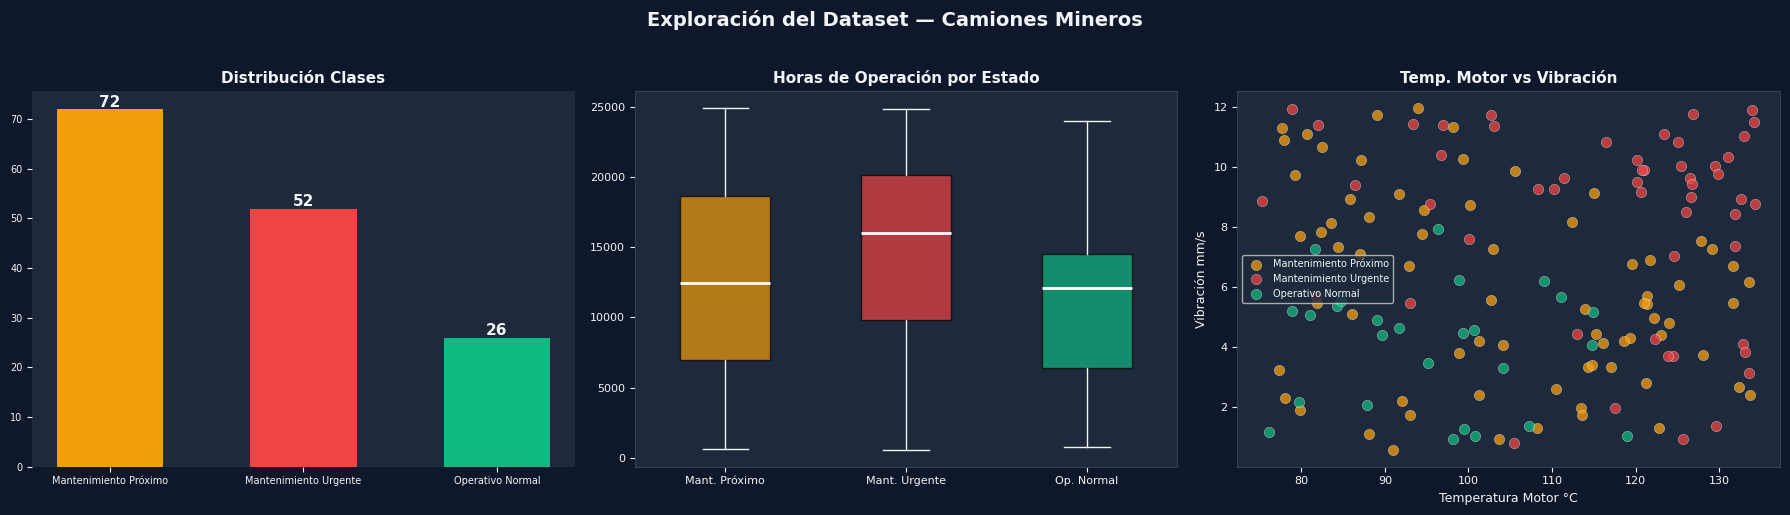

✅ EDA completado


In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Paleta ──
COLORS = {
    'Mantenimiento Próximo': '#F59E0B',
    'Mantenimiento Urgente': '#EF4444',
    'Operativo Normal':      '#10B981'
}
BG, PANEL, ACCENT = '#0F172A', '#1E293B', '#38BDF8'
TEXT = '#F1F5F9'

target_col = 'Estado_Mantenimiento'
counts = df_raw[target_col].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor=BG)
fig.suptitle('Exploración del Dataset — Camiones Mineros', fontsize=14,
             fontweight='bold', color=TEXT, y=1.02)

# Distribución target
ax = axes[0]
ax.set_facecolor(PANEL)
bars = ax.bar(counts.index, counts.values,
              color=[COLORS.get(k, ACCENT) for k in counts.index],
              edgecolor='none', width=0.55)
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha='center', fontsize=11, color=TEXT, fontweight='bold')
ax.set_title('Distribución Clases', color=TEXT, fontsize=11, fontweight='bold')
ax.tick_params(colors=TEXT, labelsize=7)
ax.spines[:].set_visible(False)
ax.set_facecolor(PANEL)

# Boxplot Horas_Operacion por clase
ax2 = axes[1]
ax2.set_facecolor(PANEL)
for i, (estado, color) in enumerate(COLORS.items()):
    subset = df_raw[df_raw[target_col] == estado]['Horas_Operacion']
    bp = ax2.boxplot(subset, positions=[i], widths=0.5, patch_artist=True,
                     medianprops=dict(color='white', linewidth=2),
                     boxprops=dict(facecolor=color, alpha=0.7),
                     whiskerprops=dict(color=TEXT), capprops=dict(color=TEXT),
                     flierprops=dict(marker='o', color=color, alpha=0.5, markersize=4))
ax2.set_xticks([0, 1, 2])
ax2.set_xticklabels(['Mant. Próximo', 'Mant. Urgente', 'Op. Normal'],
                    color=TEXT, fontsize=8)
ax2.set_title('Horas de Operación por Estado', color=TEXT, fontsize=11, fontweight='bold')
ax2.tick_params(colors=TEXT, labelsize=8)
ax2.spines[:].set_color('#334155')
ax2.set_facecolor(PANEL)

# Scatter Temperatura vs Vibración
ax3 = axes[2]
ax3.set_facecolor(PANEL)
for estado, color in COLORS.items():
    mask = df_raw[target_col] == estado
    ax3.scatter(df_raw[mask]['Temperatura_Motor_C'],
                df_raw[mask]['Vibracion_mm_s'],
                c=color, label=estado, alpha=0.75, s=55,
                edgecolors='white', linewidths=0.3)
ax3.set_xlabel('Temperatura Motor °C', color=TEXT, fontsize=9)
ax3.set_ylabel('Vibración mm/s', color=TEXT, fontsize=9)
ax3.set_title('Temp. Motor vs Vibración', color=TEXT, fontsize=11, fontweight='bold')
ax3.tick_params(colors=TEXT, labelsize=8)
ax3.spines[:].set_color('#334155')
ax3.legend(fontsize=7, facecolor=PANEL, labelcolor=TEXT, framealpha=0.8)
ax3.set_facecolor(PANEL)

plt.tight_layout()
plt.savefig('eda_exploracion.png', dpi=130, bbox_inches='tight', facecolor=BG)
plt.show()
print("✅ EDA completado")

In [5]:
# ╔══════════════════════════════════════════╗
# ║  CELDA 4 · Preprocesamiento + KNN K=5   ║
# ╚══════════════════════════════════════════╝
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance

FEATURE_COLS = [
    'Horas_Operacion', 'Temperatura_Motor_C', 'Presion_Aceite_bar',
    'Nivel_Combustible_L', 'Velocidad_Promedio_kmh', 'Carga_Toneladas',
    'Vibracion_mm_s', 'Eficiencia_Combustible', 'Km_Recorridos',
    'Dias_Ultimo_Mantenimiento', 'Año_Fabricacion'
]
TARGET_COL = 'Estado_Mantenimiento'

df = df_raw.copy()
X = df[FEATURE_COLS].astype(float)
y = df[TARGET_COL]

le = LabelEncoder()
y_enc = le.fit_transform(y)
CLASSES = le.classes_

# Escalar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_enc, test_size=0.25, random_state=42, stratify=y_enc)

# ── KNN K=5 ──
knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

# ── Cross-validation ──
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(knn, X_scaled, y_enc, cv=cv, scoring='accuracy')

# ── Feature importance ──
perm = permutation_importance(knn, X_test, y_test, n_repeats=20, random_state=42)
feat_imp = dict(zip(FEATURE_COLS, perm.importances_mean))

acc_test = accuracy_score(y_test, y_pred)
print("=" * 50)
print(f"  KNN K=5 — Resultados")
print("=" * 50)
print(f"  Accuracy (test 25%):   {acc_test:.4f}  ({acc_test:.1%})")
print(f"  CV Accuracy (5-fold):  {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print()
print(classification_report(y_test, y_pred, target_names=CLASSES))
print("✅ Modelo entrenado")


  KNN K=5 — Resultados
  Accuracy (test 25%):   0.6579  (65.8%)
  CV Accuracy (5-fold):  0.6533 ± 0.0686

                       precision    recall  f1-score   support

Mantenimiento Próximo       0.64      0.78      0.70        18
Mantenimiento Urgente       0.67      0.62      0.64        13
     Operativo Normal       0.75      0.43      0.55         7

             accuracy                           0.66        38
            macro avg       0.68      0.61      0.63        38
         weighted avg       0.67      0.66      0.65        38

✅ Modelo entrenado


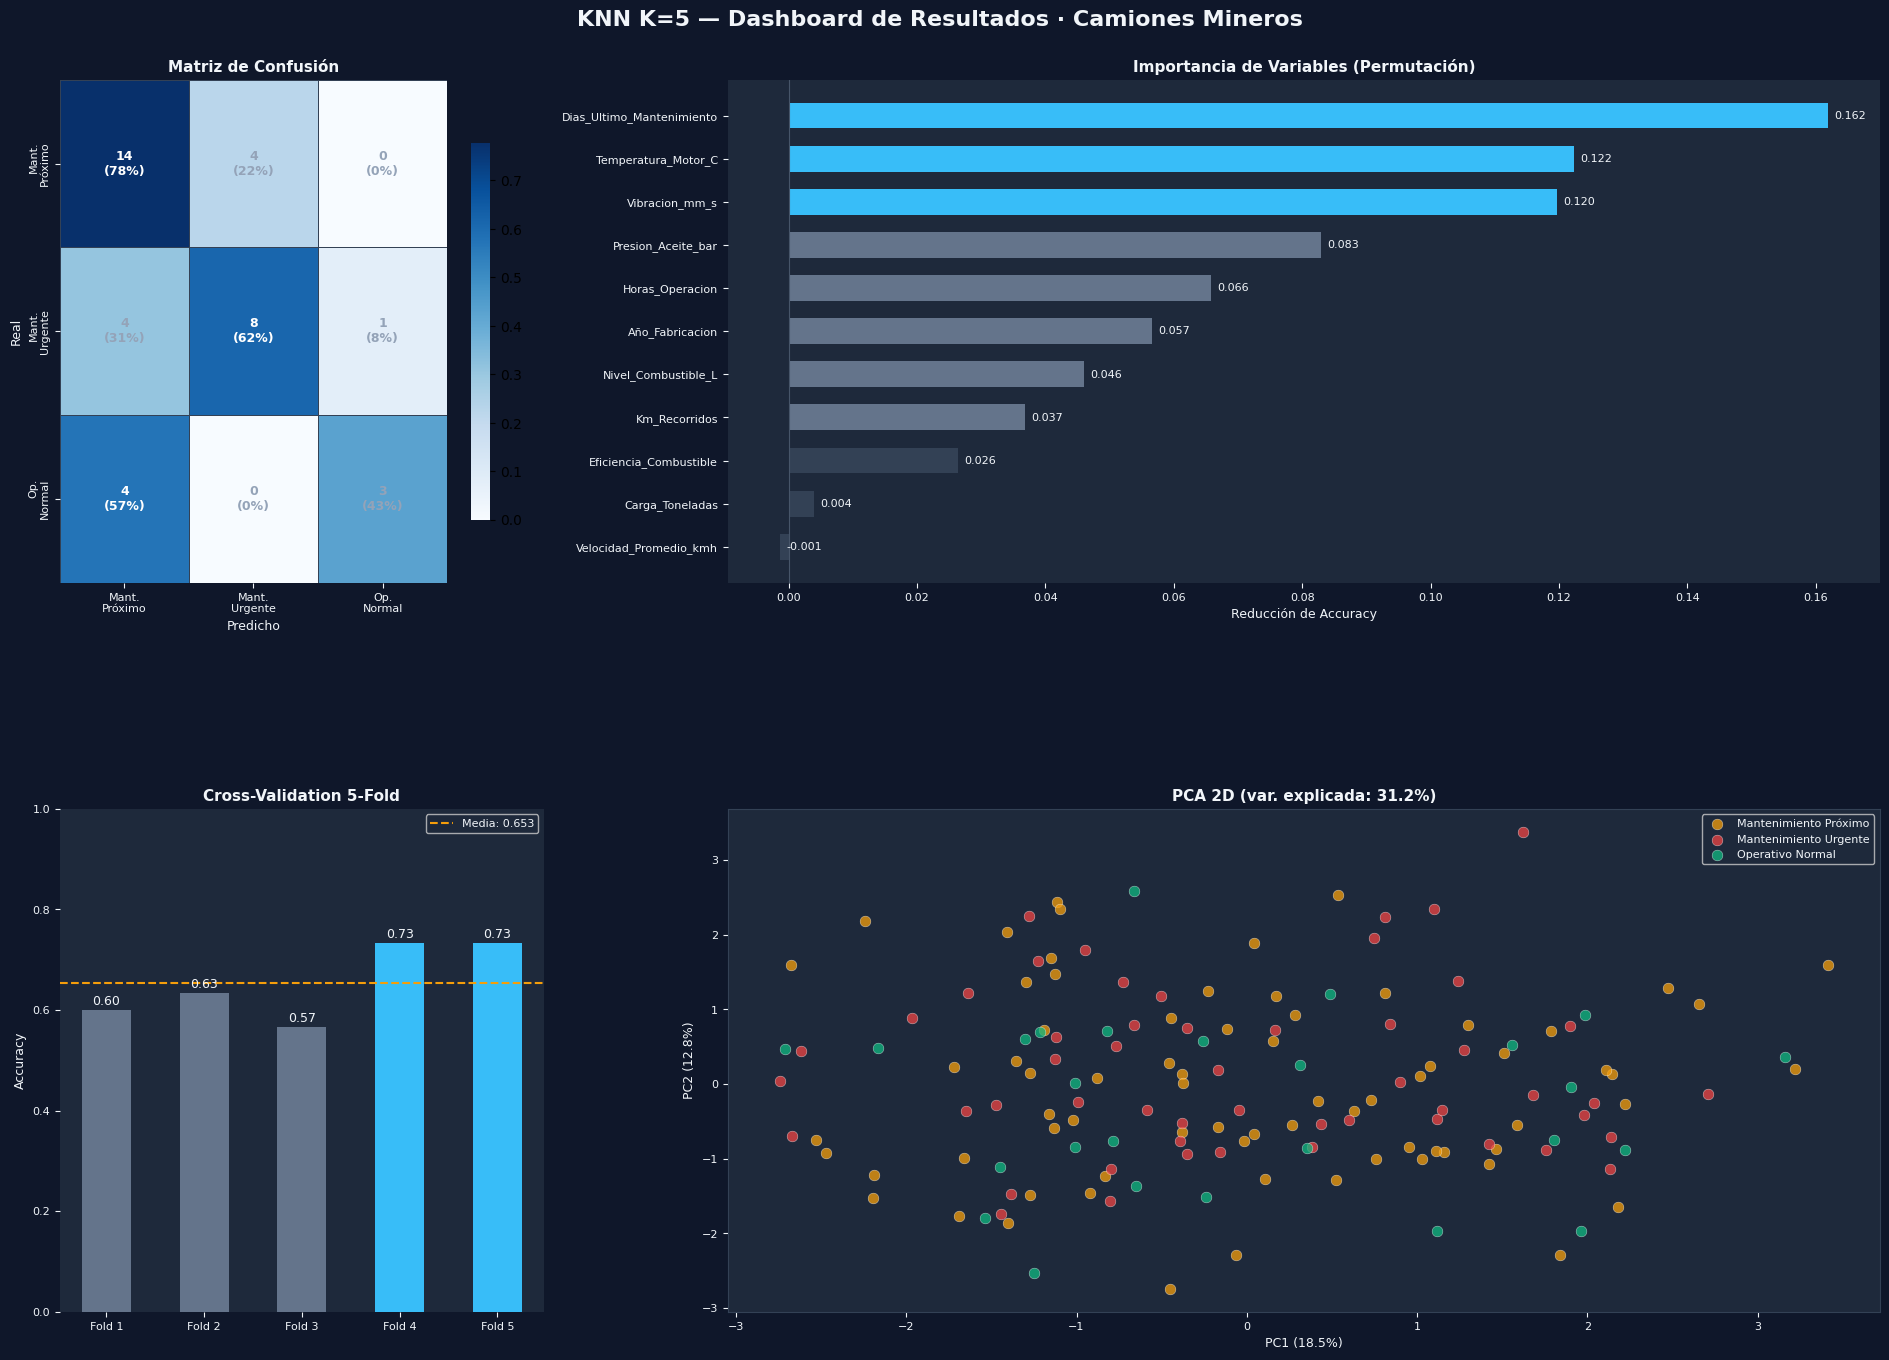

✅ Dashboard guardado como knn_dashboard.png


In [6]:
# ╔══════════════════════════════════════════╗
# ║  CELDA 5 · Visualizaciones del modelo   ║
# ╚══════════════════════════════════════════╝
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches

fig = plt.figure(figsize=(20, 14), facecolor=BG)
fig.suptitle('KNN K=5 — Dashboard de Resultados · Camiones Mineros',
             fontsize=16, fontweight='bold', color=TEXT, y=0.99)

gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.38,
                      left=0.06, right=0.97, top=0.94, bottom=0.06)

# ── 1. Confusion Matrix ──
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(PANEL)
cm = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
labels_s = ['Mant.\nPróximo', 'Mant.\nUrgente', 'Op.\nNormal']
sns.heatmap(cm_norm, annot=False, ax=ax1, cmap='Blues',
            linewidths=0.5, linecolor='#334155',
            xticklabels=labels_s, yticklabels=labels_s,
            cbar_kws={'shrink': 0.75})
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        clr = 'white' if cm_norm[i,j] > 0.45 else '#94A3B8'
        ax1.text(j+0.5, i+0.5, f'{cm[i,j]}\n({cm_norm[i,j]:.0%})',
                 ha='center', va='center', fontsize=9, color=clr, fontweight='bold')
ax1.set_title('Matriz de Confusión', color=TEXT, fontsize=11, fontweight='bold')
ax1.set_xlabel('Predicho', color=TEXT, fontsize=9)
ax1.set_ylabel('Real', color=TEXT, fontsize=9)
ax1.tick_params(colors=TEXT, labelsize=8)

# ── 2. Feature Importance ──
ax2 = fig.add_subplot(gs[0, 1:])
ax2.set_facecolor(PANEL)
fi_sorted = sorted(feat_imp.items(), key=lambda x: x[1])
names, vals = zip(*fi_sorted)
bar_colors = [ACCENT if v > 0.1 else '#64748B' if v > 0.03 else '#334155' for v in vals]
bars2 = ax2.barh(names, vals, color=bar_colors, edgecolor='none', height=0.6)
ax2.set_title('Importancia de Variables (Permutación)', color=TEXT, fontsize=11, fontweight='bold')
ax2.set_xlabel('Reducción de Accuracy', color=TEXT, fontsize=9)
ax2.tick_params(colors=TEXT, labelsize=8)
ax2.spines[:].set_visible(False)
ax2.axvline(0, color='#475569', lw=0.8)
for bar, val in zip(bars2, vals):
    ax2.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', fontsize=8, color=TEXT)
ax2.set_facecolor(PANEL)

# ── 3. CV Scores ──
ax3 = fig.add_subplot(gs[1, 0])
ax3.set_facecolor(PANEL)
fold_labels = [f'Fold {i+1}' for i in range(5)]
b_colors = [ACCENT if s >= cv_scores.mean() else '#64748B' for s in cv_scores]
ax3.bar(fold_labels, cv_scores, color=b_colors, edgecolor='none', width=0.5)
ax3.axhline(cv_scores.mean(), color='#F59E0B', lw=1.5, ls='--',
            label=f'Media: {cv_scores.mean():.3f}')
ax3.set_title('Cross-Validation 5-Fold', color=TEXT, fontsize=11, fontweight='bold')
ax3.set_ylabel('Accuracy', color=TEXT, fontsize=9)
ax3.set_ylim(0, 1)
ax3.tick_params(colors=TEXT, labelsize=8)
ax3.spines[:].set_visible(False)
ax3.legend(fontsize=8, facecolor=PANEL, labelcolor=TEXT)
for i, v in enumerate(cv_scores):
    ax3.text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=9, color=TEXT)
ax3.set_facecolor(PANEL)

# ── 4. PCA scatter ──
ax4 = fig.add_subplot(gs[1, 1:])
ax4.set_facecolor(PANEL)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
cls_colors = ['#F59E0B', '#EF4444', '#10B981']
for i, (cls, clr) in enumerate(zip(CLASSES, cls_colors)):
    mask = y_enc == i
    ax4.scatter(X_pca[mask, 0], X_pca[mask, 1], c=clr, label=cls,
                alpha=0.75, s=60, edgecolors='white', linewidths=0.3)
ax4.set_title(f'PCA 2D (var. explicada: {sum(pca.explained_variance_ratio_):.1%})',
              color=TEXT, fontsize=11, fontweight='bold')
ax4.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', color=TEXT, fontsize=9)
ax4.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', color=TEXT, fontsize=9)
ax4.tick_params(colors=TEXT, labelsize=8)
ax4.spines[:].set_color('#334155')
ax4.legend(fontsize=8, facecolor=PANEL, labelcolor=TEXT)
ax4.set_facecolor(PANEL)

plt.savefig('knn_dashboard.png', dpi=130, bbox_inches='tight', facecolor=BG)
plt.show()
print("✅ Dashboard guardado como knn_dashboard.png")


In [8]:
# ╔══════════════════════════════════════════════════════╗
# ║  CELDA 6 · Construir Excel con predicciones          ║
# ╚══════════════════════════════════════════════════════╝
import numpy as np
import pandas as pd
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.inspection import permutation_importance
import warnings
warnings.filterwarnings('ignore')

# ── Re-entrenar si las variables no están en scope ──
try:
    _ = knn
except NameError:
    print("⚠️  Re-entrenando modelo (ejecuta las celdas en orden para evitar esto)...")
    FEATURE_COLS = [
        'Horas_Operacion', 'Temperatura_Motor_C', 'Presion_Aceite_bar',
        'Nivel_Combustible_L', 'Velocidad_Promedio_kmh', 'Carga_Toneladas',
        'Vibracion_mm_s', 'Eficiencia_Combustible', 'Km_Recorridos',
        'Dias_Ultimo_Mantenimiento', 'Año_Fabricacion'
    ]
    TARGET_COL = 'Estado_Mantenimiento'
    df = df_raw.copy()
    X = df[FEATURE_COLS].astype(float)
    y = df[TARGET_COL]
    le = LabelEncoder()
    y_enc = le.fit_transform(y)
    CLASSES = le.classes_
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y_enc, test_size=0.25, random_state=42, stratify=y_enc)
    knn = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = cross_val_score(knn, X_scaled, y_enc, cv=cv, scoring='accuracy')
    perm = permutation_importance(knn, X_test, y_test, n_repeats=20, random_state=42)
    feat_imp = dict(zip(FEATURE_COLS, perm.importances_mean))
    print("✅ Modelo re-entrenado correctamente")

# ── Predicciones sobre TODO el dataset ──
y_pred_all  = knn.predict(X_scaled)
y_proba_all = knn.predict_proba(X_scaled)

df_out = df.copy()
df_out['Prediccion_KNN']        = le.inverse_transform(y_pred_all)
df_out['Prob_Mant_Proximo']     = y_proba_all[:, 0].round(3)
df_out['Prob_Mant_Urgente']     = y_proba_all[:, 1].round(3)
df_out['Prob_Operativo_Normal'] = y_proba_all[:, 2].round(3)
df_out['Confianza_Max']         = y_proba_all.max(axis=1).round(3)
df_out['Correcto']              = df_out[TARGET_COL] == df_out['Prediccion_KNN']

idx_all = np.arange(len(df))
_, idx_test_ = train_test_split(idx_all, test_size=0.25, random_state=42, stratify=y_enc)
df_out['Conjunto'] = 'Entrenamiento'
df_out.loc[idx_test_, 'Conjunto'] = 'Prueba'

def generar_insight(row):
    msgs = []
    if row['Confianza_Max'] < 0.6:
        msgs.append("⚠️ Baja confianza — revisar manualmente")
    if row['Prediccion_KNN'] == 'Mantenimiento Urgente':
        msgs.append("🚨 Requiere atención inmediata")
    if row['Prediccion_KNN'] == 'Mantenimiento Próximo':
        msgs.append("🔧 Programar mantenimiento próximo")
    if row['Prediccion_KNN'] == 'Operativo Normal':
        msgs.append("✅ En condición óptima")
    if not row['Correcto'] and row['Conjunto'] == 'Prueba':
        msgs.append("❌ Predicción incorrecta en prueba")
    return " | ".join(msgs)

df_out['Insight'] = df_out.apply(generar_insight, axis=1)

# ── Helpers de estilo (sin # en los hex para openpyxl) ──
_BG     = '0F172A'
_PANEL  = '1E293B'
_PANEL2 = '172033'
_ACCENT = '38BDF8'
_GREEN  = '10B981'
_YELLOW = 'F59E0B'
_RED    = 'EF4444'
_PURPLE = 'A78BFA'
_WHITE  = 'F1F5F9'
_GRAY   = '64748B'

ESTADO_COLORS = {
    'Mantenimiento Próximo': _YELLOW,
    'Mantenimiento Urgente': _RED,
    'Operativo Normal':      _GREEN,
}

def _fill(h):
    h = h.lstrip('#')   # elimina # si viene con él
    return PatternFill('solid', start_color=h, fgColor=h)

def _font(color='F1F5F9', bold=False, size=9):
    color = color.lstrip('#')
    return Font(name='Arial', bold=bold, color=color, size=size)

def _center(): return Alignment(horizontal='center', vertical='center', wrap_text=True)
def _left():   return Alignment(horizontal='left',   vertical='center')

def _border():
    s = Side(style='thin', color='334155')
    return Border(left=s, right=s, top=s, bottom=s)

# ══════════════════════════════════
# Workbook
# ══════════════════════════════════
wb = Workbook()

# ── HOJA 1: Predicciones ──
ws1 = wb.active
ws1.title = 'Predicciones KNN'
ws1.sheet_view.showGridLines = False
ws1.sheet_properties.tabColor = _ACCENT

ws1.merge_cells('A1:Q1')
ws1['A1'] = '🚛  KNN K=5 — Predicciones de Mantenimiento | Camiones Mineros'
ws1['A1'].font  = Font(name='Arial', bold=True, size=13, color=_ACCENT)
ws1['A1'].fill  = _fill(_BG)
ws1['A1'].alignment = _center()
ws1.row_dimensions[1].height = 34

ws1.merge_cells('A2:Q2')
ws1['A2'] = (f'Dataset: {len(df_out)} registros  |  K = 5  |  '
             f'Accuracy global: {df_out["Correcto"].mean():.1%}  |  '
             f'CV Accuracy: {cv_scores.mean():.1%} ± {cv_scores.std():.2f}')
ws1['A2'].font  = Font(name='Arial', size=9, color=_GRAY)
ws1['A2'].fill  = _fill(_BG)
ws1['A2'].alignment = _center()
ws1.row_dimensions[2].height = 20

HEADERS   = ['ID Camión','Modelo','Año','Horas Op.','Temp °C','Presión bar',
             'Comb. L','Vel km/h','Carga Ton','Vibr mm/s','Días Ult.Mant',
             'Estado Real','Predicción KNN','Confianza','Correcto','Conjunto','Insight']
COL_KEYS  = ['ID_Camion','Modelo','Año_Fabricacion','Horas_Operacion',
             'Temperatura_Motor_C','Presion_Aceite_bar','Nivel_Combustible_L',
             'Velocidad_Promedio_kmh','Carga_Toneladas','Vibracion_mm_s',
             'Dias_Ultimo_Mantenimiento','Estado_Mantenimiento','Prediccion_KNN',
             'Confianza_Max','Correcto','Conjunto','Insight']
COL_WIDTHS = [11,15,7,11,10,12,10,10,10,10,13,22,22,11,10,14,38]

ws1.row_dimensions[3].height = 26
for ci, (h, w) in enumerate(zip(HEADERS, COL_WIDTHS), 1):
    c = ws1.cell(row=3, column=ci, value=h)
    c.font  = Font(name='Arial', bold=True, size=9, color='0F172A')
    c.fill  = _fill(_ACCENT)
    c.alignment = _center()
    c.border = _border()
    ws1.column_dimensions[get_column_letter(ci)].width = w

for ri, (_, row) in enumerate(df_out.iterrows(), start=4):
    rbg     = _PANEL if ri % 2 == 0 else _PANEL2
    correct = row['Correcto']
    ws1.row_dimensions[ri].height = 18

    for ci, key in enumerate(COL_KEYS, 1):
        val  = row[key]
        cell = ws1.cell(row=ri, column=ci)
        cell.border    = _border()
        cell.alignment = _left() if key in ['Modelo', 'Insight'] else _center()

        if key in ['Horas_Operacion','Km_Recorridos','Año_Fabricacion','Dias_Ultimo_Mantenimiento']:
            cell.value = int(val) if str(val) != 'nan' else ''
            cell.number_format = '#,##0'
        elif key in ['Temperatura_Motor_C','Presion_Aceite_bar','Nivel_Combustible_L',
                     'Velocidad_Promedio_kmh','Carga_Toneladas','Vibracion_mm_s']:
            cell.value = round(float(val), 1)
            cell.number_format = '#,##0.0'
        elif key == 'Confianza_Max':
            cell.value = float(val)
            cell.number_format = '0%'
            conf    = float(val)
            c_color = _GREEN if conf >= 0.8 else (_YELLOW if conf >= 0.6 else _RED)
            cell.font = Font(name='Arial', size=9, color=c_color, bold=True)
            cell.fill = _fill(rbg)
            continue
        elif key == 'Correcto':
            cell.value = '✅' if val else '❌'
            cell.font  = Font(name='Arial', size=10, color=_GREEN if val else _RED, bold=True)
            cell.fill  = _fill(rbg)
            continue
        elif key == 'Estado_Mantenimiento':
            cell.value = val
            cell.font  = Font(name='Arial', size=9, bold=True,
                              color=ESTADO_COLORS.get(str(val), _GRAY))
            cell.fill  = _fill(rbg)
            continue
        elif key == 'Prediccion_KNN':
            cell.value = val
            cell.font  = Font(name='Arial', size=9, bold=True,
                              color=ESTADO_COLORS.get(str(val), _GRAY))
            cell.fill  = _fill('2D1B1B') if not correct else _fill(rbg)
            continue
        elif key == 'Conjunto':
            cell.value = val
            cell.font  = Font(name='Arial', size=9,
                              color=_ACCENT if val == 'Prueba' else _GRAY)
            cell.fill  = _fill(rbg)
            continue
        elif key == 'Insight':
            cell.value = val
            cell.font  = Font(name='Arial', size=8,
                              color='94A3B8' if '✅' in str(val) else _YELLOW)
            cell.fill  = _fill(rbg)
            continue
        else:
            cell.value = val

        cell.font = _font()
        cell.fill = _fill(rbg)

ws1.freeze_panes = 'A4'
ws1.auto_filter.ref = f'A3:Q{3 + len(df_out)}'

# ── HOJA 2: Resumen & Insights ──
ws2 = wb.create_sheet('Resumen & Insights')
ws2.sheet_view.showGridLines = False
ws2.sheet_properties.tabColor = _GREEN
for col in range(1, 10):
    ws2.column_dimensions[get_column_letter(col)].width = 22

ws2.merge_cells('A1:I1')
ws2['A1'] = '📊  Resumen de Resultados KNN K=5 — Camiones Mineros'
ws2['A1'].font = Font(name='Arial', bold=True, size=13, color=_ACCENT)
ws2['A1'].fill = _fill(_BG)
ws2['A1'].alignment = _center()
ws2.row_dimensions[1].height = 34

kpis = [
    ('Accuracy Test',     f'{accuracy_score(y_test, y_pred):.1%}',          _ACCENT),
    ('CV Accuracy',       f'{cv_scores.mean():.1%} ±{cv_scores.std():.2f}', _PURPLE),
    ('Total Registros',   '150',                                              _WHITE),
    ('Correctos (total)', str(df_out["Correcto"].sum()),                       _GREEN),
    ('Erróneos (total)',  str((~df_out["Correcto"]).sum()),                    _RED),
    ('K Vecinos',         '5',                                                _YELLOW),
    ('Métrica',           'Euclidiana',                                       _GRAY),
]

ws2.merge_cells('A3:I3')
ws2['A3'] = 'INDICADORES CLAVE'
ws2['A3'].font = Font(name='Arial', bold=True, size=9, color=_GRAY)
ws2['A3'].fill = _fill(_BG)
ws2['A3'].alignment = _left()
ws2.row_dimensions[3].height = 20

for ci, (lbl, val, col) in enumerate(kpis, 1):
    lc = ws2.cell(row=4, column=ci, value=lbl)
    lc.font = Font(name='Arial', size=8, color=_GRAY)
    lc.fill = _fill(_PANEL); lc.alignment = _center(); lc.border = _border()
    vc = ws2.cell(row=5, column=ci, value=val)
    vc.font = Font(name='Arial', bold=True, size=12, color=col)
    vc.fill = _fill(_PANEL); vc.alignment = _center(); vc.border = _border()
ws2.row_dimensions[4].height = 18
ws2.row_dimensions[5].height = 28

# Distribución
ws2.merge_cells('A7:E7')
ws2['A7'] = 'DISTRIBUCIÓN REAL vs PREDICHA'
ws2['A7'].font = Font(name='Arial', bold=True, size=9, color=_GRAY)
ws2['A7'].fill = _fill(_BG); ws2['A7'].alignment = _left()
ws2.row_dimensions[7].height = 20

for ci, h in enumerate(['Estado','Real (n)','Predicho (n)','Diferencia','F1-Score'], 1):
    c = ws2.cell(row=8, column=ci, value=h)
    c.font = Font(name='Arial', bold=True, size=9, color='0F172A')
    c.fill = _fill(_ACCENT); c.alignment = _center(); c.border = _border()
ws2.row_dimensions[8].height = 22

report_dict = classification_report(y_test, y_pred, target_names=CLASSES, output_dict=True)
ESTADOS = ['Mantenimiento Próximo', 'Mantenimiento Urgente', 'Operativo Normal']
for ri, (est, rbg) in enumerate(zip(ESTADOS, [_PANEL, _PANEL2, _PANEL]), start=9):
    real_n = (df_out[TARGET_COL] == est).sum()
    pred_n = (df_out['Prediccion_KNN'] == est).sum()
    diff   = pred_n - real_n
    f1     = report_dict.get(est, {}).get('f1-score', 0)
    ws2.row_dimensions[ri].height = 20
    for ci, val in enumerate([est, real_n, pred_n, diff, f'{f1:.1%}'], 1):
        c = ws2.cell(row=ri, column=ci, value=val)
        c.border = _border(); c.alignment = _center(); c.fill = _fill(rbg)
        if ci == 1:
            c.font = Font(name='Arial', bold=True, size=9, color=ESTADO_COLORS.get(est, _GRAY))
        elif ci == 4:
            c_col = _GREEN if diff == 0 else (_YELLOW if abs(diff) <= 5 else _RED)
            c.font = Font(name='Arial', size=9, bold=True, color=c_col)
        elif ci == 5:
            c_col = _GREEN if f1 >= 0.7 else (_YELLOW if f1 >= 0.55 else _RED)
            c.font = Font(name='Arial', size=9, bold=True, color=c_col)
        else:
            c.font = _font()

# Matriz de confusión
ws2.merge_cells('A13:E13')
ws2['A13'] = 'MATRIZ DE CONFUSIÓN (test 25%)'
ws2['A13'].font = Font(name='Arial', bold=True, size=9, color=_GRAY)
ws2['A13'].fill = _fill(_BG); ws2['A13'].alignment = _left()
ws2.row_dimensions[13].height = 20

cm_matrix = confusion_matrix(y_test, y_pred)
ls = ['Mant. Próximo', 'Mant. Urgente', 'Op. Normal']
hdr = ws2.cell(row=14, column=1, value='Real / Predicho')   # ← sin backslash
hdr.font = Font(name='Arial', bold=True, size=8, color=_GRAY)
hdr.fill = _fill(_BG); hdr.alignment = _center(); hdr.border = _border()
ws2.row_dimensions[14].height = 22

for ci, l in enumerate(ls, 2):
    c = ws2.cell(row=14, column=ci, value=l)
    c.font = Font(name='Arial', bold=True, size=8, color='0F172A')
    c.fill = _fill(_ACCENT); c.alignment = _center(); c.border = _border()

for ri, (rl, cm_row) in enumerate(zip(ls, cm_matrix), start=15):
    ws2.row_dimensions[ri].height = 22
    rc = ws2.cell(row=ri, column=1, value=rl)
    rc.font = Font(name='Arial', bold=True, size=8, color=ESTADO_COLORS[ESTADOS[ri-15]])
    rc.fill = _fill(_PANEL); rc.alignment = _center(); rc.border = _border()
    for ci, val in enumerate(cm_row, 2):
        c = ws2.cell(row=ri, column=ci, value=int(val))
        c.border = _border(); c.alignment = _center()
        is_diag = (ri - 15) == (ci - 2)
        if is_diag:
            c.fill = _fill('1A3A2A')
            c.font = Font(name='Arial', bold=True, size=11, color=_GREEN)
        else:
            c.fill = _fill('2D1B1B') if val > 0 else _fill(_PANEL)
            c.font = Font(name='Arial', size=10, color=_RED if val > 0 else _GRAY)

# Métricas por clase
ws2.merge_cells('A20:F20')
ws2['A20'] = 'MÉTRICAS POR CLASE (conjunto prueba)'
ws2['A20'].font = Font(name='Arial', bold=True, size=9, color=_GRAY)
ws2['A20'].fill = _fill(_BG); ws2['A20'].alignment = _left()
ws2.row_dimensions[20].height = 20

for ci, h in enumerate(['Clase','Precision','Recall','F1-Score','Soporte','Evaluación'], 1):
    c = ws2.cell(row=21, column=ci, value=h)
    c.font = Font(name='Arial', bold=True, size=9, color='0F172A')
    c.fill = _fill(_ACCENT); c.alignment = _center(); c.border = _border()
ws2.row_dimensions[21].height = 22

for ri, (est, rbg) in enumerate(zip(ESTADOS, [_PANEL, _PANEL2, _PANEL]), start=22):
    r = report_dict.get(est, {})
    prec = r.get('precision', 0); rec = r.get('recall', 0)
    f1   = r.get('f1-score', 0);  sup = int(r.get('support', 0))
    verdict = '✅ Bueno' if f1 >= 0.7 else ('⚠️ Aceptable' if f1 >= 0.55 else '❌ Mejorar')
    ws2.row_dimensions[ri].height = 20
    for ci, val in enumerate([est, prec, rec, f1, sup, verdict], 1):
        c = ws2.cell(row=ri, column=ci, value=val)
        c.border = _border(); c.fill = _fill(rbg); c.alignment = _center()
        if ci == 1:
            c.font = Font(name='Arial', bold=True, size=9, color=ESTADO_COLORS.get(est, _GRAY))
        elif ci in [2, 3, 4]:
            c.number_format = '0.00'
            sc = _GREEN if float(val) >= 0.7 else (_YELLOW if float(val) >= 0.55 else _RED)
            c.font = Font(name='Arial', size=9, color=sc, bold=True)
        elif ci == 6:
            vc = _GREEN if '✅' in str(val) else (_YELLOW if '⚠️' in str(val) else _RED)
            c.font = Font(name='Arial', size=9, color=vc, bold=True)
        else:
            c.font = _font()

# Top 5 variables
ws2.merge_cells('A27:D27')
ws2['A27'] = 'TOP 5 VARIABLES MÁS IMPORTANTES'
ws2['A27'].font = Font(name='Arial', bold=True, size=9, color=_GRAY)
ws2['A27'].fill = _fill(_BG); ws2['A27'].alignment = _left()
ws2.row_dimensions[27].height = 20

for ci, h in enumerate(['Variable','Importancia','Ranking','Observación'], 1):
    c = ws2.cell(row=28, column=ci, value=h)
    c.font = Font(name='Arial', bold=True, size=9, color='0F172A')
    c.fill = _fill(_ACCENT); c.alignment = _center(); c.border = _border()
ws2.row_dimensions[28].height = 22

obs_map = {
    'Dias_Ultimo_Mantenimiento': '⏰ Principal predictor de urgencia',
    'Temperatura_Motor_C':       '🌡️ Estrés térmico del motor',
    'Vibracion_mm_s':            '📳 Desgaste mecánico',
    'Presion_Aceite_bar':        '🛢️ Estado lubricación',
    'Horas_Operacion':           '⏱️ Desgaste acumulado',
}
fi_sorted_all = sorted(feat_imp.items(), key=lambda x: x[1], reverse=True)
medals = ['🥇','🥈','🥉','4️⃣','5️⃣']
for ri, (var, imp) in enumerate(fi_sorted_all[:5], start=29):
    rbg = _PANEL if ri % 2 == 0 else _PANEL2
    obs = obs_map.get(var, '—')
    ws2.row_dimensions[ri].height = 20
    for ci, val in enumerate([var, round(imp, 4), f'{medals[ri-29]} #{ri-28}', obs], 1):
        c = ws2.cell(row=ri, column=ci, value=val)
        c.border = _border(); c.fill = _fill(rbg); c.alignment = _center()
        if ci == 1:
            c.font = Font(name='Arial', bold=True, size=9,
                          color=_ACCENT if imp > 0.1 else _WHITE)
        elif ci == 2:
            c.number_format = '0.000'
            c_col = _ACCENT if imp > 0.1 else (_YELLOW if imp > 0.05 else _GRAY)
            c.font = Font(name='Arial', size=9, bold=True, color=c_col)
        elif ci == 3:
            c.font = Font(name='Arial', size=10, color=_YELLOW)
        else:
            c.font = Font(name='Arial', size=9, color='94A3B8')

# Insights finales
insights_txt = [
    '💡 Insight 1: "Días desde último mantenimiento" es el predictor más potente — revisar rutinas de mantenimiento preventivo',
    '💡 Insight 2: Temperatura y vibración explican conjuntamente ~24% de la predicción — monitorear sensores en tiempo real',
    '⚠️  Riesgo: "Mantenimiento Urgente" tiene recall 62% — complementar con reglas heurísticas para casos de baja confianza',
    '🎯 Recomendación: Aumentar dataset y probar Random Forest / SVM para superar el 66% de accuracy',
]
for ri, txt in enumerate(insights_txt, start=36):
    ws2.merge_cells(f'A{ri}:I{ri}')
    ws2[f'A{ri}'] = txt
    ws2[f'A{ri}'].font  = Font(name='Arial', size=9,
                                color=_YELLOW if '💡' in txt else _RED)
    ws2[f'A{ri}'].fill  = _fill(_PANEL)
    ws2[f'A{ri}'].alignment = _left()
    ws2[f'A{ri}'].border = _border()
    ws2.row_dimensions[ri].height = 20

# Fondo oscuro en celdas vacías
for ws in [ws1, ws2]:
    for row in ws.iter_rows():
        for cell in row:
            rgb = cell.fill.fgColor.rgb if cell.fill.patternType else '00000000'
            if rgb in ('00000000', '', '000000', None):
                cell.fill = _fill(_BG)

OUTPUT_FILE = 'predicciones_knn_k5_camiones.xlsx'
wb.save(OUTPUT_FILE)
print(f"✅ Excel generado: {OUTPUT_FILE}")
print(f"   Hoja 1: {len(df_out)} filas con predicciones, probabilidades e insights")
print(f"   Hoja 2: Resumen, métricas, matriz de confusión, top variables")


✅ Excel generado: predicciones_knn_k5_camiones.xlsx
   Hoja 1: 150 filas con predicciones, probabilidades e insights
   Hoja 2: Resumen, métricas, matriz de confusión, top variables


In [9]:
# ╔══════════════════════════════════════════╗
# ║  CELDA 7 · Descargar resultado           ║
# ╚══════════════════════════════════════════╝
from google.colab import files

files.download('predicciones_knn_k5_camiones.xlsx')
files.download('knn_dashboard.png')
files.download('eda_exploracion.png')

print("✅ Archivos descargados:")
print("   📊 predicciones_knn_k5_camiones.xlsx  — Dataset con predicciones e insights")
print("   🖼️  knn_dashboard.png                 — Dashboard de métricas del modelo")
print("   🖼️  eda_exploracion.png               — Exploración inicial del dataset")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Archivos descargados:
   📊 predicciones_knn_k5_camiones.xlsx  — Dataset con predicciones e insights
   🖼️  knn_dashboard.png                 — Dashboard de métricas del modelo
   🖼️  eda_exploracion.png               — Exploración inicial del dataset
